Gráficos salvos em: training_metrics.png

Métricas de Teste:
test_acc     0.903264
test_f1      0.903264
test_iou     0.736261
test_loss    0.381779
Name: 3913, dtype: float64


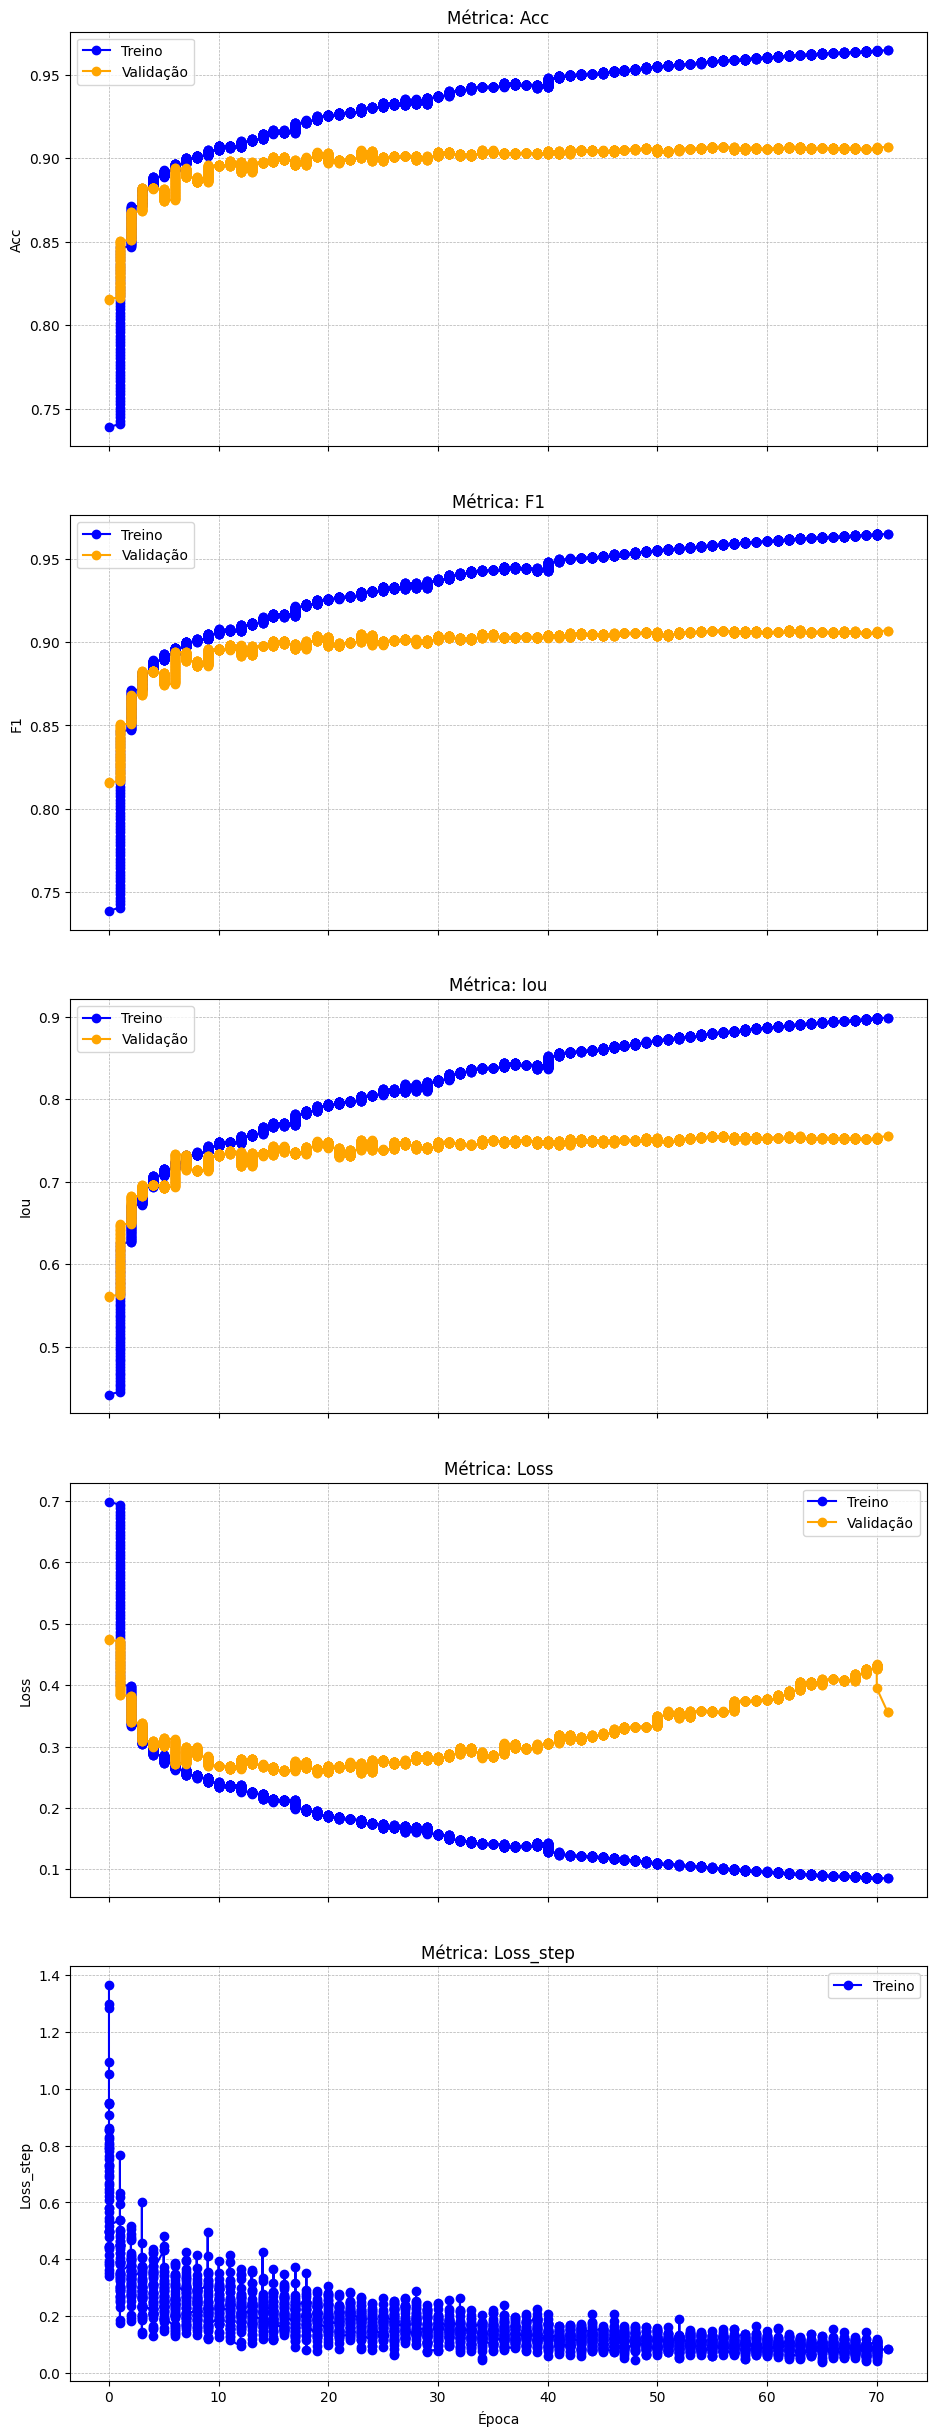

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_metrics(csv_path):
    """
    Lê um arquivo CSV de métricas do PyTorch Lightning e plota as métricas de
    treino e validação.

    Args:
        csv_path (str): O caminho para o arquivo metrics.csv.
    """
    if not os.path.exists(csv_path):
        print(f"Arquivo não encontrado em: {csv_path}")
        # Criando um DataFrame de exemplo se o arquivo não existir
        print("Criando um DataFrame de exemplo para demonstração.")
        data = {
            'epoch': range(10),
            'train_loss': np.random.rand(10) * 0.5 + 0.1,
            'val_loss': np.random.rand(10) * 0.3 + 0.2,
            'train_acc': np.linspace(0.7, 0.9, 10),
            'val_acc': np.linspace(0.75, 0.88, 10),
            'test_loss': [0.25],
            'test_acc': [0.86]
        }
        metrics_df = pd.DataFrame(data)
    else:
        metrics_df = pd.read_csv(csv_path)
        
    if 'train_loss_epoch' in metrics_df.columns:
        metrics_df = metrics_df.rename(columns={'train_loss_epoch': 'train_loss'})
        
    # Obter os nomes das métricas base (sem os prefixos 'train_' e 'val_')
    columns = metrics_df.columns
    metric_names = set()
    for col in columns:
        if 'train_' in col:
            metric_names.add(col.replace('train_', ''))
        elif 'val_' in col:
            metric_names.add(col.replace('val_', ''))

    metric_names = sorted(list(metric_names))
    num_metrics = len(metric_names)
    
    

    if num_metrics == 0:
        print("Nenhuma métrica de treino ou validação encontrada no arquivo.")
        return

    # Criar subplots para cada métrica
    fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 5 * num_metrics), sharex=True)
    if num_metrics == 1:
        axes = [axes] # Garante que 'axes' seja sempre uma lista

    for i, metric in enumerate(metric_names):
        ax = axes[i]
        train_metric_col = f'train_{metric}'
        val_metric_col = f'val_{metric}'

        # Plotar métricas de treino
        if train_metric_col in metrics_df.columns:
            # Interpolar para lidar com possíveis NaNs em épocas intermediárias
            train_values = metrics_df[train_metric_col].interpolate()
            ax.plot(metrics_df['epoch'], train_values, label='Treino', color='blue', marker='o')

        # Plotar métricas de validação
        if val_metric_col in metrics_df.columns:
            # Interpolar para lidar com possíveis NaNs
            val_values = metrics_df[val_metric_col].interpolate()
            ax.plot(metrics_df['epoch'], val_values, label='Validação', color='orange', marker='o')

        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'Métrica: {metric.capitalize()}')
        ax.legend()
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    axes[-1].set_xlabel('Época')
    fig.tight_layout(pad=3.0)
    
    # Salvar a figura
    save_path = 'training_metrics.png'
    #plt.savefig(save_path)
    print(f"Gráficos salvos em: {save_path}")

    # Exibir as métricas de teste, se existirem
    test_metrics = [col for col in metrics_df.columns if 'test_' in col]
    if test_metrics:
        print("\nMétricas de Teste:")
        # Pega a primeira linha que não seja NaN para as métricas de teste
        test_results = metrics_df[test_metrics].dropna().iloc[0]
        print(test_results)


# --- Como usar ---
# Coloque o caminho para o seu arquivo de métricas aqui
# Por exemplo: 'lightning_logs/version_0/metrics.csv'
csv_file_path = "C:\\Users\\alanb\\Documents\\lightning_logs\\l1c_segformer_mit-b2_4bandas\\version_0\\metrics.csv"
plot_metrics(csv_file_path)

Coluna 'train_loss_epoch' encontrada. Renomeando para 'train_loss' para unificação.

Gráficos salvos em: training_metrics_analysis.png


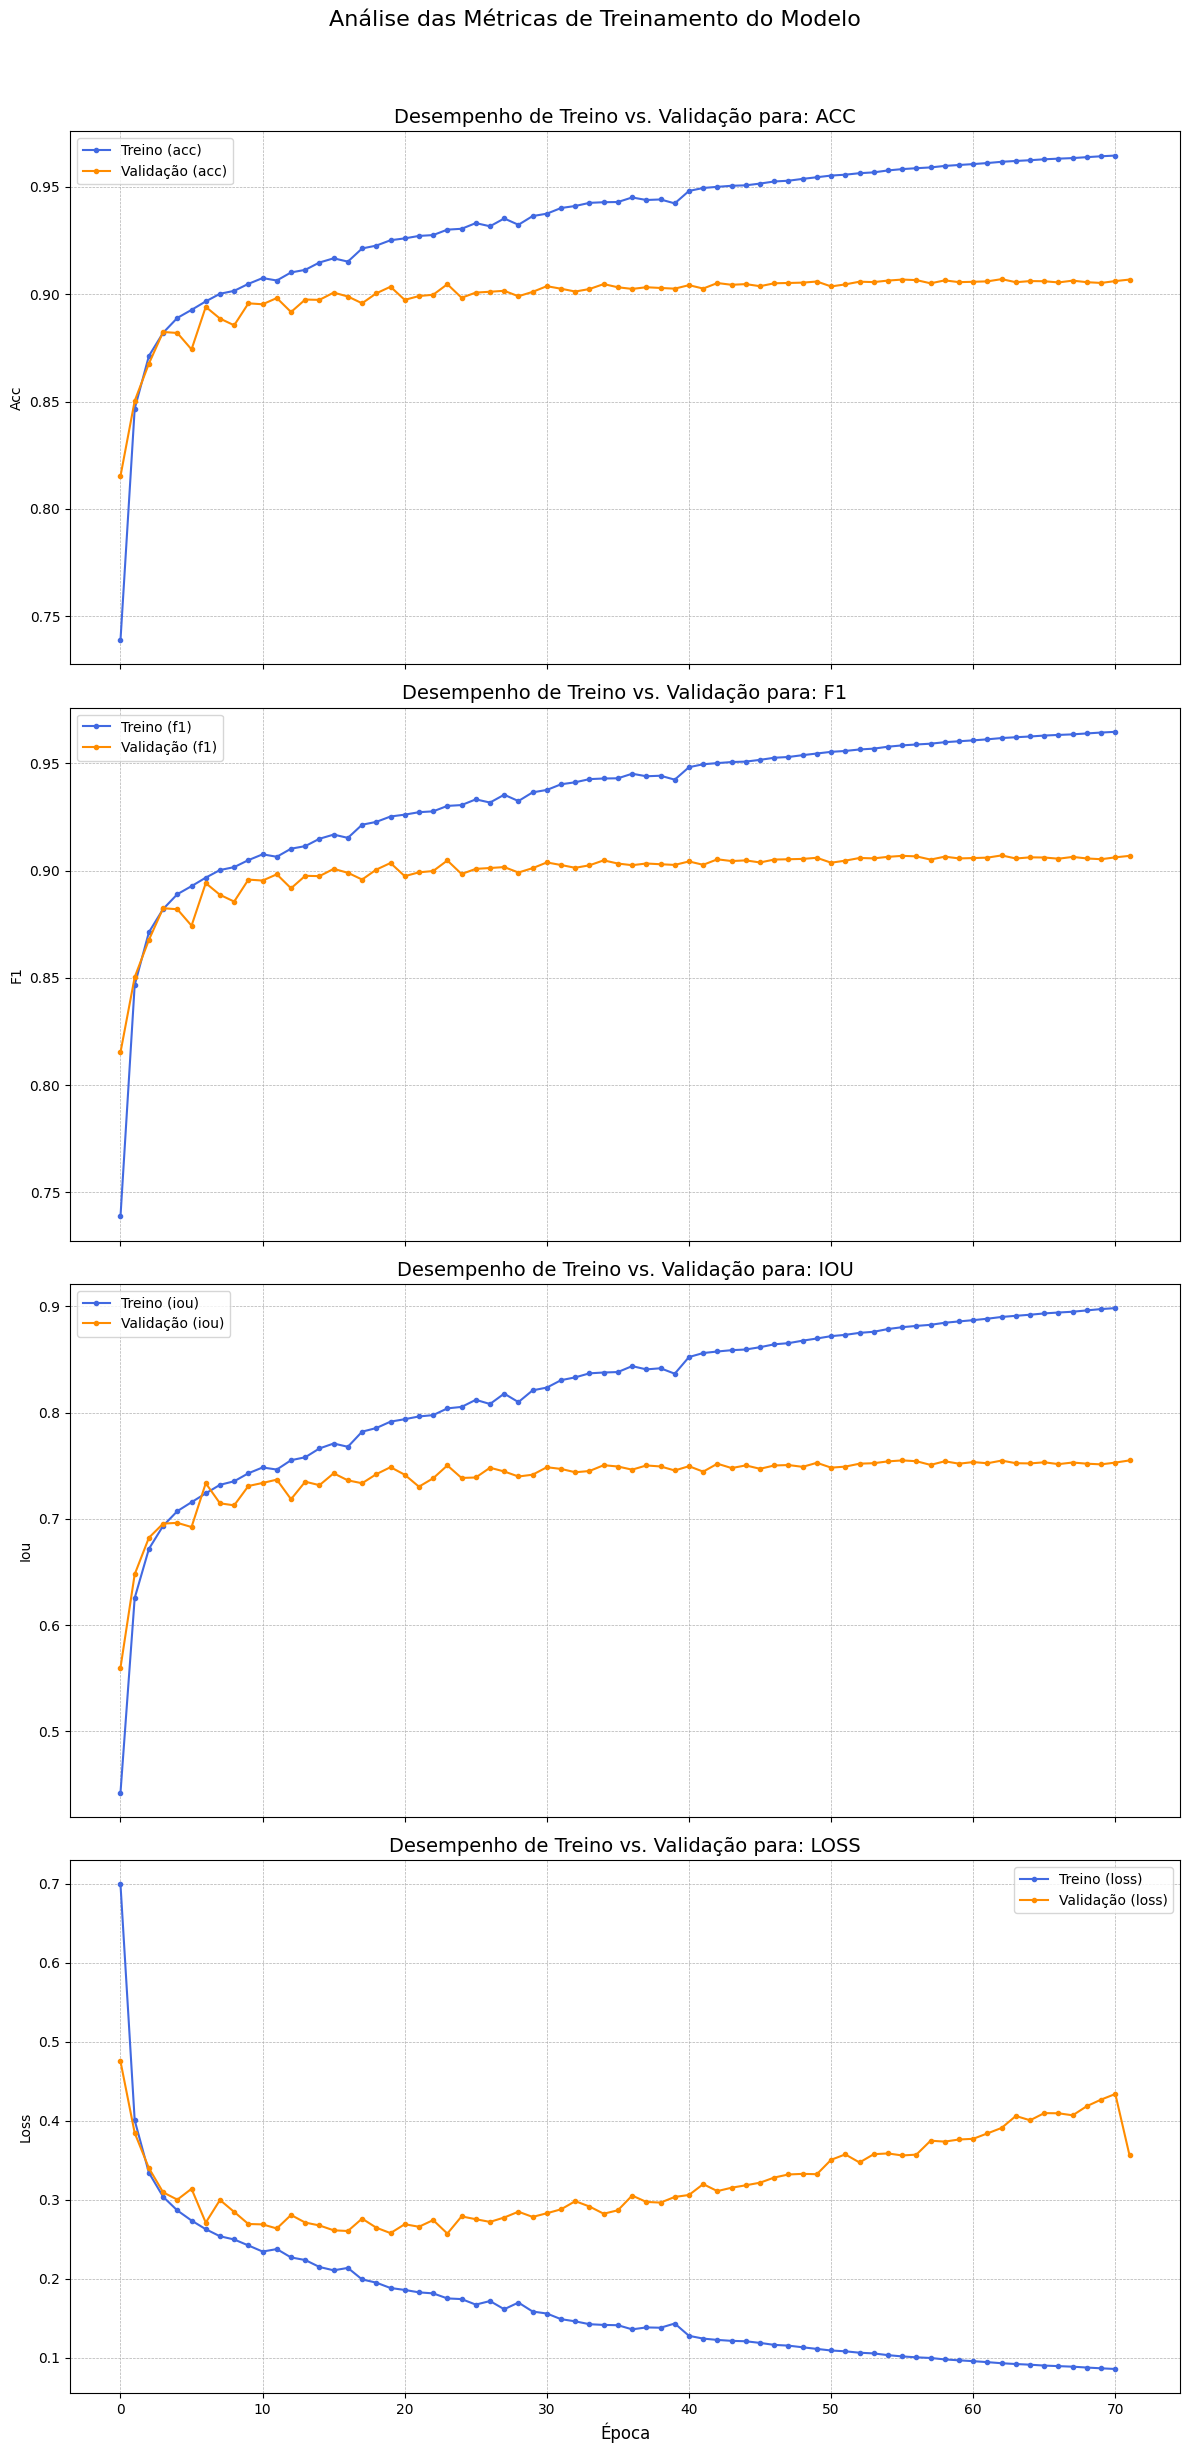

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_metrics_from_file(csv_path):
    """
    Lê um arquivo CSV de métricas do PyTorch Lightning e plota as métricas de
    treino e validação.

    Args:
        csv_path (str): O caminho para o arquivo metrics.csv.
    """
    if not os.path.exists(csv_path):
        print(f"Arquivo não encontrado em: {csv_path}")
        return

    metrics_df = pd.read_csv(csv_path)

    # --- PONTO CHAVE: UNIFICAÇÃO DOS NOMES DAS MÉTRICAS DE PERDA ---
    # Verificamos se a coluna 'train_loss_epoch' existe. Se sim,
    # nós a renomeamos para 'train_loss'.
    # Isso garante que ela seja agrupada com 'val_loss' para plotagem.
    if 'train_loss_epoch' in metrics_df.columns:
        print("Coluna 'train_loss_epoch' encontrada. Renomeando para 'train_loss' para unificação.")
        metrics_df = metrics_df.rename(columns={'train_loss_epoch': 'train_loss'})
    # ----------------------------------------------------------------

    # Obter os nomes das métricas base (sem os prefixos 'train_' e 'val_')
    columns = metrics_df.columns
    metric_names = set()
    for col in columns:
        if 'train_' in col and '_step' not in col: # Ignorar métricas de step
             metric_names.add(col.replace('train_', ''))
        elif 'val_' in col:
            metric_names.add(col.replace('val_', ''))

    # Garantir que apenas métricas com par (treino e validação) sejam plotadas
    metrics_to_plot = []
    for metric in metric_names:
        if f'train_{metric}' in metrics_df.columns and f'val_{metric}' in metrics_df.columns:
            metrics_to_plot.append(metric)

    metric_names = sorted(list(metrics_to_plot))
    num_metrics = len(metric_names)

    if num_metrics == 0:
        print("Nenhuma métrica de treino/validação correspondente encontrada para plotar.")
        return

    # Criar subplots para cada métrica
    fig, axes = plt.subplots(num_metrics, 1, figsize=(12, 6 * num_metrics), sharex=True)
    if num_metrics == 1:
        axes = [axes]

    # Agrupar por época para garantir que tenhamos um ponto de dados por época
    epoch_df = metrics_df.groupby('epoch').last().reset_index()

    for i, metric in enumerate(metric_names):
        ax = axes[i]
        train_metric_col = f'train_{metric}'
        val_metric_col = f'val_{metric}'

        ax.plot(epoch_df['epoch'], epoch_df[train_metric_col], label=f'Treino ({metric})', color='royalblue', marker='.', linestyle='-')
        ax.plot(epoch_df['epoch'], epoch_df[val_metric_col], label=f'Validação ({metric})', color='darkorange', marker='.', linestyle='-')

        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'Desempenho de Treino vs. Validação para: {metric.upper()}', fontsize=14)
        ax.legend()
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    axes[-1].set_xlabel('Época', fontsize=12)
    fig.suptitle('Análise das Métricas de Treinamento do Modelo', fontsize=16, y=1.02)
    fig.tight_layout()

    save_path = 'training_metrics_analysis.png'
    plt.savefig(save_path)
    print(f"\nGráficos salvos em: {save_path}")

# --- Como usar ---
csv_file_path = "C:\\Users\\alanb\\Documents\\lightning_logs\\l1c_segformer_mit-b2_4bandas\\version_0\\metrics.csv"
plot_metrics_from_file(csv_file_path)